## W2W
1. Как модель работает:  CBOW
Вход: контекст (слова слева и справа)
    ↓
Среднее/сумма их векторов
    ↓
Полносвязный слой + softmax
    ↓
Выход: вероятность каждого слова словаря (цель — предсказать центральное слово)
SkipGram
Вход: вектор центрального слова
    ↓
Полносвязный слой
    ↓
Множество softmax (по контекстным словам)
    ↓
Выход: вероятности слов в контексте


2. задача Извлечение смысловых аналогий, поиск лексических замен
3. Семантические эмбединги ( W2W, Fast text, Bert)
4. Словари (RuWordNet) и контекстные модели (Bert, Seq2seq)

In [1]:
!pip install numpy==1.26.4 scipy==1.11.1

In [2]:
!pip install gensim==4.3.1

In [3]:
import gensim
print(gensim.__version__)

4.3.3


In [4]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
import pymorphy2

filename = r'Zhitiya_raw\Ioann_Zlatoust.txt'  # файл с текстом
lemmatized_filename = r'Zhitiya_raw\Ioann_Zlatoust_lem.txt'  # файл для лемматизированного текста

morph = pymorphy2.MorphAnalyzer()

# Считываем стоп-слова из файла
with open('stopwords-ru.txt', 'r', encoding='utf-8') as f:
    stopwords = set(line.strip().lower() for line in f if line.strip())

# Лемматизация с удалением стоп-слов
with open(filename, 'r', encoding='utf-8') as fin, open(lemmatized_filename, 'w', encoding='utf-8') as fout:
    for line in fin:
        words = line.strip().split()
        lemmas = []
        for word in words:
            p = morph.parse(word)[0]
            lemma = p.normal_form
            if lemma not in stopwords:
                lemmas.append(lemma)
        fout.write(' '.join(lemmas) + '\n')


# Обучаем модель на лемматизированном тексте
model = Word2Vec(
    LineSentence(lemmatized_filename), #reading by line
    vector_size=150, #vector size for a word
    window=1, #left and right context
    min_count=5,#ignore rare words
    workers=2, # number of streams
    sg=1  # Skip-gram вместо CBOW
)

model.init_sims(replace=True)
model.save('w2w_Zlatoust_lem.model')


C:\Users\alena\AppData\Local\Temp\ipykernel_25652\1708719055.py:37: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  model.init_sims(replace=True)


In [19]:
# Загружаем модель
model = Word2Vec.load('w2w_Zlatoust_lem.model')

In [20]:
# Функция, чтобы показать похожие слова
def print_similar_words(word, topn=10):
    print(f"Похожие слова для '{word}':")
    similar = model.wv.most_similar(positive=[word], topn=topn)
    for w, score in similar:
        print(f"  {w} -> {score:.4f}")
    print()

In [21]:
# Проверяем похожие слова для нескольких слов
words_to_test = ['муж', 'город']
for w in words_to_test:
    print_similar_words(w)

Похожие слова для 'муж':
  феофил -> 0.5197
  царь -> 0.5088
  иоанна. -> 0.4871
  находиться -> 0.4748
  народ -> 0.4743
  сан -> 0.4523
  церкви, -> 0.4487
  церковь -> 0.4486
  обвинение -> 0.4472
  том, -> 0.4390

Похожие слова для 'город':
  время -> 0.5818
  иметь -> 0.5601
  царица -> 0.5457
  церковь -> 0.5409
  против -> 0.5363
  возвратиться -> 0.5320
  находиться -> 0.5292
  иоанна, -> 0.5214
  феофил -> 0.5189
  – -> 0.5187



In [22]:
# Считаем сходство между двумя словами
similarity_score = model.wv.similarity('муж', 'народ')
print(f"Сходство между 'вера' и 'народ': {similarity_score:.4f}\n")

Сходство между 'вера' и 'народ': 0.4743



Можно посчитать, насколько близки по смыслу два слова. Результат — число от -1 до 1 (больше значит более похожи).

In [23]:
# Функция для визуализации слов с помощью t-SNE
def tsnescatterplot(model, word, additional_words=[]):  # строит вектора для заданного слова + его ближайших + дополнительных
    sns.set_style("darkgrid")  # устанавливаем стиль графика

    arrays = np.empty((0, model.vector_size), dtype='f')  # создаём пустой массив для векторов слов
    word_labels = [word]     # список подписей для точек (начинаем с целевого слова)
    color_list = ['red']     # список цветов для точек (целевое слово — красное)

    # Добавляем вектор целевого слова
    arrays = np.append(arrays, model.wv[word].reshape(1, -1), axis=0)

    # Получаем 10 ближайших слов и добавляем их в массив векторов
    close_words = model.wv.most_similar([word], topn=20)
    for wrd, _ in close_words:
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)  # добавляем вектор
        word_labels.append(wrd)               # добавляем подпись
        color_list.append('blue')             # цвет — синий для похожих слов

    # Добавляем дополнительные слова, если указаны
    for wrd in additional_words:
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)  # добавляем вектор
        word_labels.append(wrd)               # добавляем подпись
        color_list.append('green')            # цвет — зелёный для вручную указанных слов

    # Сначала понижаем размерность до 4 с помощью PCA — ускоряет работу t-SNE
    pca_result = PCA(n_components=4).fit_transform(arrays)

    # Затем понижаем до 2D с помощью t-SNE для визуализации
    tsne = TSNE(n_components=2, perplexity=min(5, len(arrays)), n_iter=1000, random_state=0)
    tsne_result = tsne.fit_transform(pca_result)

    # Создаём DataFrame с координатами, подписями и цветами
    df = pd.DataFrame({
        'x': tsne_result[:, 0],       # координата X
        'y': tsne_result[:, 1],       # координата Y
        'word': word_labels,          # подпись (слово)
        'color': color_list           # цвет точки
    })

    # Настраиваем размер фигуры и строим scatter plot
    plt.figure(figsize=(10, 10))
    sns.scatterplot(data=df, x='x', y='y', hue='color', palette=['red', 'blue', 'green'], legend=False, s=100)

    # Добавляем текстовые подписи к точкам
    for i in range(len(df)):
        plt.text(df.x[i]+0.1, df.y[i]+0.1, df.word[i], fontsize=12)

    # Добавляем заголовок и отображаем график
    plt.title(f't-SNE визуализация для слова: {word}')
    plt.show()


C:\Users\alena\AppData\Roaming\Python\Python310\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\alena\AppData\Local\Temp\ipykernel_25652\1844276144.py:42: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(data=df, x='x', y='y', hue='color', palette=['red', 'blue', 'green'], legend=False, s=100)


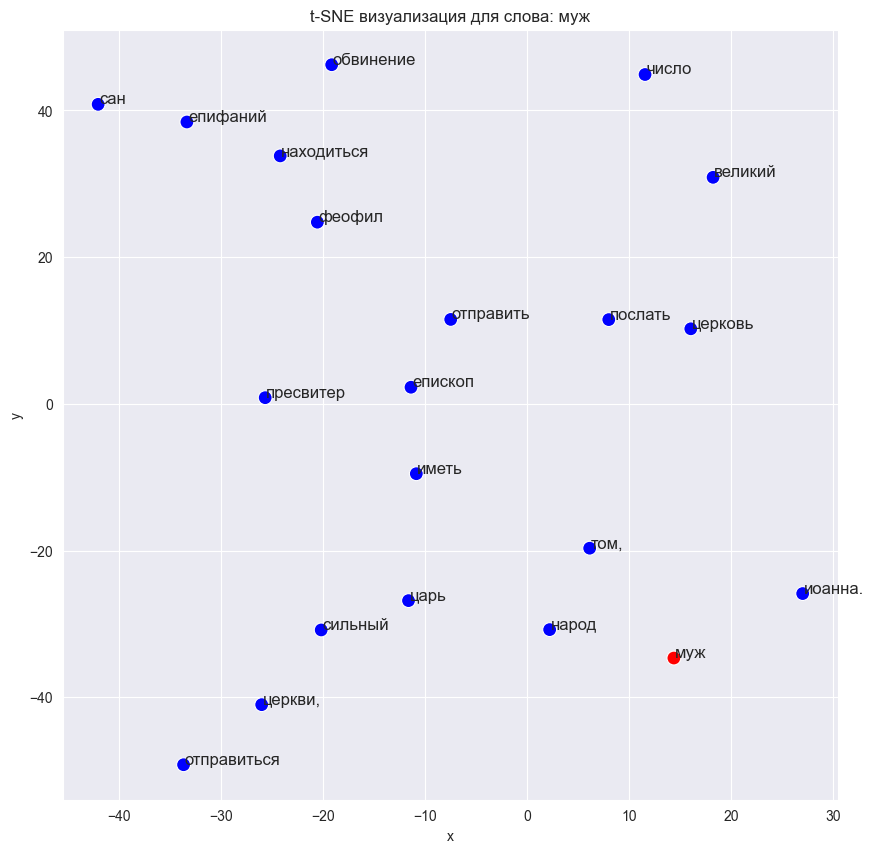

In [24]:
# Визуализируем слово
tsnescatterplot(model, 'муж')

Обучение модели на тексте о Иона Златоусте. Поиск семантического сходства. 